# Nesso-1 on 50 additional Runs N' Poses systems

## Question

The original 100-system experiment showed that Nesso's structural predictions
were better for complexes resembling pre-September-2021 PDB complexes. It also
looked as though performance changed sharply near a familiarity score of 50.

We therefore selected **50 additional Runs N' Poses records**, excluding the
exact original 100 records, and repeated the same Nesso-1 inference and
coordinate-free structural scoring protocol.

The new cohort has unique clusters, PDB entries, and ligand SMILES internally.
Across cohorts, 14 structural clusters recur, so pooled uncertainty intervals
resample complete clusters rather than treating all 150 records as independent.

**Result:** the broad familiarity trend reproduces. A universal threshold at
50 does not.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def repository_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "reports").is_dir() and (candidate / "configs").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside BindingAffinityPredictor")


ROOT = repository_root(Path.cwd())
RESULTS = ROOT / "reports/exp013_nesso1_rnp_confirmation50/results"
comparison = json.loads((RESULTS / "comparison.json").read_text())
systems = pd.read_csv(RESULTS / "combined_per_system_metrics.csv")

assert comparison["cohort_overlap_count"] == 0
assert len(systems) == 150
systems.groupby("cohort").size()


/home/yusheng/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/yusheng/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


cohort
confirmation_50     50
discovery_100      100
dtype: int64

## 1. What does Spearman $\rho$ tell us?

Spearman $\rho$ asks whether two quantities have a consistent rank ordering.
For errors such as distogram NLL and distance MAE, a negative value means
errors decrease as familiarity increases. For contact AP and pocket F1, a
positive value means accuracy increases with familiarity.

The confirmation cohort should be read independently of the original cohort.
If both show the same direction and their uncertainty intervals exclude zero,
the qualitative trend has replicated.


In [2]:
metrics = {
    "Distogram NLL ↓": "interface_distogram_nll",
    "Distance MAE ↓": "interface_expected_distance_mae_angstrom",
    "Contact AP ↑": "token_contact_average_precision_at_6a",
    "Pocket F1 ↑": "physical_pocket_f1_at_6a",
}
cohort_labels = {
    "discovery_100": "Original 100",
    "confirmation_50": "New 50",
    "combined_150": "Combined 150",
}
rows = []
for cohort, label in cohort_labels.items():
    aggregate = comparison["aggregates"][cohort]
    for metric_label, metric in metrics.items():
        result = aggregate["spearman_vs_familiarity"][metric]
        rows.append({
            "Cohort": label,
            "Metric": metric_label,
            "rho": result["rho"],
            "CI lower": result["lower_95"],
            "CI upper": result["upper_95"],
        })
rho_table = pd.DataFrame(rows)
display(rho_table.pivot(index="Metric", columns="Cohort", values="rho").round(3))


Cohort,Combined 150,New 50,Original 100
Metric,,,
Contact AP ↑,0.649,0.529,0.682
Distance MAE ↓,-0.686,-0.630,-0.709
Distogram NLL ↓,-0.651,-0.513,-0.704
Pocket F1 ↑,0.638,0.625,0.647


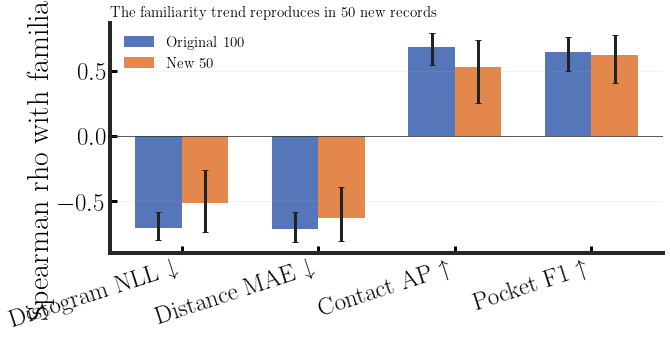

In [3]:
fig, ax = plt.subplots(figsize=(9.2, 4.6), constrained_layout=True)
x = np.arange(len(metrics))
width = 0.34
for offset, cohort, color in [
    (-width / 2, "discovery_100", "#4267B2"),
    (width / 2, "confirmation_50", "#E07A38"),
]:
    selected = rho_table[rho_table["Cohort"] == cohort_labels[cohort]].set_index("Metric")
    selected = selected.loc[list(metrics)]
    values = selected["rho"].to_numpy()
    low = values - selected["CI lower"].to_numpy()
    high = selected["CI upper"].to_numpy() - values
    ax.bar(x + offset, values, width, label=cohort_labels[cohort], color=color, alpha=0.9)
    ax.errorbar(x + offset, values, yerr=np.vstack([low, high]), fmt="none", color="#222", capsize=3)
ax.axhline(0, color="#333", linewidth=0.8)
ax.set_xticks(x, list(metrics), rotation=18, ha="right")
ax.set_ylabel("Spearman rho with familiarity")
ax.set_title("The familiarity trend reproduces in 50 new records", loc="left", weight="bold")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
plt.show()


All four confirmation-cohort correlations point in the expected direction,
and all four 95% bootstrap intervals exclude zero:

- distance MAE: $\rho=-0.630$;
- contact AP: $\rho=+0.529$;
- pocket F1: $\rho=+0.625$.

Nesso's interface entropy also continues to track distance error in the new 50
($\rho=+0.701$). This is evidence that the broad familiarity dependence was
not peculiar to the first selected sample.


## 2. Does performance jump specifically at 50?

For this diagnostic, we compare the median metric in the 40--50 bin with the
median in the 50--60 bin. This is an exploratory comparison, not a fitted or
pre-established biological threshold.


In [4]:
boundary_rows = []
for cohort in ("discovery_100", "confirmation_50", "combined_150"):
    for metric_label, metric in metrics.items():
        result = comparison["boundary_40_50_vs_50_60"][cohort][metric]
        boundary_rows.append({
            "Cohort": cohort_labels[cohort],
            "Metric": metric_label,
            "40–50 median": result["median_40_50"],
            "50–60 median": result["median_50_60"],
            "Difference": result["observed_difference"],
            "95% lower": result["bootstrap_lower_95"],
            "95% upper": result["bootstrap_upper_95"],
        })
boundary = pd.DataFrame(boundary_rows)
display(boundary[boundary["Cohort"] == "New 50"].set_index("Metric").round(3))


,Cohort,40–50 median,50–60 median,Difference,95% lower,95% upper
Metric,,,,,,
Distogram NLL ↓,New 50,2.237,3.203,0.966,-0.978,1.099
Distance MAE ↓,New 50,0.876,0.907,0.031,-1.466,0.729
Contact AP ↑,New 50,0.905,0.779,-0.127,-0.379,0.472
Pocket F1 ↑,New 50,0.414,0.760,0.346,0.000,0.530


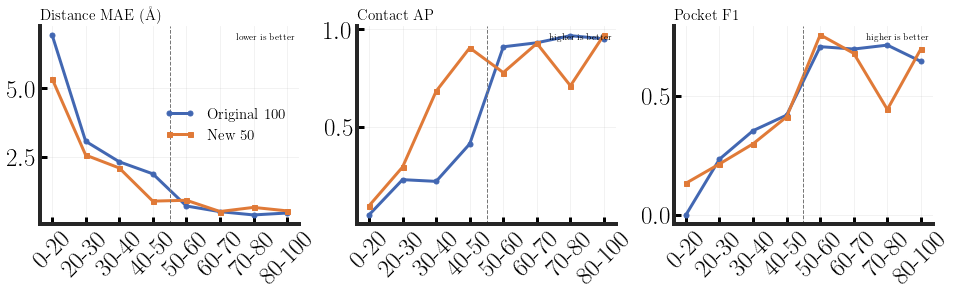

In [5]:
bins = ["0-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-100"]
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.0), constrained_layout=True)
panels = [
    ("interface_expected_distance_mae_angstrom", "Distance MAE (Å)", "lower is better"),
    ("token_contact_average_precision_at_6a", "Contact AP", "higher is better"),
    ("physical_pocket_f1_at_6a", "Pocket F1", "higher is better"),
]
for ax, (metric, title, direction) in zip(axes, panels):
    for cohort, color, marker in [
        ("discovery_100", "#4267B2", "o"),
        ("confirmation_50", "#E07A38", "s"),
    ]:
        aggregate = comparison["aggregates"][cohort]
        values = [aggregate["by_familiarity_bin"][b]["metrics"][metric]["median"] for b in bins]
        ax.plot(bins, values, marker=marker, color=color, label=cohort_labels[cohort])
    ax.axvline(3.5, color="#777", linestyle="--", linewidth=1)
    ax.set_title(title, loc="left", weight="bold")
    ax.text(0.98, 0.96, direction, transform=ax.transAxes, ha="right", va="top", fontsize=9)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False)
plt.show()


The exact jump did **not** replicate for distogram NLL, distance MAE, or
contact AP. In the new cohort, the 40--50 bin already performed well, and the
50--60 bin was similar or slightly worse. Pocket F1 did improve in both
cohorts.

## Conclusion

1. **Robust result:** Nesso's structural representation is substantially more
   accurate for systems structurally familiar to its training era.
2. **Robust uncertainty result:** higher Nesso interface entropy tends to mean
   larger structural error.
3. **Not supported:** a universal performance transition exactly at score 50.
4. **Possible narrower hypothesis:** pocket recovery may change strongly near
   this region, but testing that requires denser sampling and a predeclared
   changepoint analysis.
